Init and define utility func()

In [267]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt

N = 10
MAX_SCOPE = 1000
INIT_SPEED = 10
R_ALIGHNMENT = 20
R_REPULSE = 5
R_SIGHT = 40
R_CAUGHT = 3
DELTA_T = 0.01
MCS = 1000

class Vector:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def distance(self, another_one):
        return math.sqrt( min((self.x - another_one.x) ** 2, (MAX_SCOPE - abs(self.x - another_one.x))**2 )
                          + min((self.y - another_one.y) **2, (MAX_SCOPE - abs(self.y - another_one.y))**2 ))

    def move(self, speed, delta_t: float) -> None: # speed is also a vector
        self.x = (self.x + speed.x * delta_t) % MAX_SCOPE  # periodic boundary
        self.y = (self.y + speed.y * delta_t) % MAX_SCOPE  # periodic boundary
    def inverse(self):
        self.x *= -1
        self.y *= -1

class Animal:
    def __init__(self, name, _id, **kwargs):
        self.name = name  # wolf or sheep
        self.id = _id
        self.alive = True
        self.pos =  kwargs["pos"] # this is a vector
        self.speed = kwargs["speed"] # this is a vector

    def distance(self, other_animal  ):
        return self.pos.distance( other_animal.pos )

    def calculate_align_pulse(self, herd : [], force_0: Vector) -> Vector:
        nearby_herd = [ h for h in herd if self.distance(h) <= R_ALIGHNMENT ]
        self.speed.x = sum( [h.speed.x for h in nearby_herd])
        self.speed.y = sum( [h.speed.y for h in nearby_herd])

        # close_herd =  [ h for h in herd if self.distance(h) <= R_REPULSE ]
        # todo
        return force_0
    def calculate_chase_escape(self, herd:[], force_0:Vector) -> Vector:
        close_herd =  [ h for h in herd if self.distance(h) <= R_SIGHT ]
        caught_herd = [ h for h in close_herd if self.distance(h) <= R_CAUGHT ]
        if ( len(caught_herd) >0 ):
            if (self.name == "sheep"):
                self.alive = False
                print(f"sheep-{self.id} is dead")
                return Vector(0,0)
            else:
                for h in caught_herd:
                    h.alive = False
                    print(f"sheep-{h.id} is dead")
                close_herd = list(set(close_herd) - set(caught_herd))
        #todo
        return force_0

    def calculate_force(self, herd : [], force_0: Vector) -> Vector:
        if (self.name == herd[0].name) :
            return self.calculate_align_pulse( herd, force_0)
        else:
            force = self.calculate_chase_escape( herd, force_0)
            if ( self.name == "sheep" ):
                force.inverse()
        return force

    def update_speed(self, delta_t):
        force = self.calculate_force( Wolves, Vector(0,0))
        force = self.calculate_force( alive_animals( Sheep), force)
        gaussian = np.random.normal(0,1,2)
        self.speed.x = self.speed.x + force.x * delta_t + gaussian[0] * delta_t
        self.speed.y = self.speed.y + force.y * delta_t + gaussian[1] * delta_t
        pass

    def move(self, delta_t : float ):
        self.update_speed(delta_t)
        self.pos.move(self.speed, delta_t)

def alive_animals( animals :[] ) -> []:
    return [ a for a in animals if a.alive ]

def draw():
    plt.figure(1)  # 选择图表1
    x = [w.pos.x for w in Wolves]
    y = [w.pos.y for w in Wolves]
    plt.scatter(x, y, marker='D')

    x = [s.pos.x for s in alive_animals(Sheep) ]
    y = [s.pos.y for s in alive_animals(Sheep) ]
    plt.scatter(x, y, marker='+')

5.0


In [269]:
def unit_test():
    assert (Vector(0,3).distance( Vector(4,0)) ==5)

    # w1 = Animal("wolf", 1, pos= Vector(10,10), speed = Vector(3,1))
    # assert( w1.pos.x == 10 and w1.pos.y == 10)
    # w1.move(1)
    # assert( w1.pos.x == 13 and w1.pos.y == 11) given alignment effect, it's not

    v1 = Vector(1, 1)
    v2 = Vector(MAX_SCOPE -2, MAX_SCOPE -3)
    assert ( v1.distance(v2) == 5)

    print("all passed")

unit_test()

all passed


In [39]:
def init() :
    positions_wolf = [Vector(p[0], p[1]) for p in zip(np.random.randint(0, MAX_SCOPE / 3, N),
                                                      np.random.randint(0, MAX_SCOPE / 3, N))]
    positions_sheep = [Vector(p[0], p[1]) for p in zip(np.random.randint(MAX_SCOPE / 2, MAX_SCOPE, N),
                                                       np.random.randint(MAX_SCOPE / 2, MAX_SCOPE, N))]
    speed_wolf = [Vector(p[0], p[1]) for p in zip(np.random.randint(INIT_SPEED/2, INIT_SPEED, N),
                          np.random.randint(INIT_SPEED/2, INIT_SPEED, N) )]
    speed_sheep = [Vector(p[0], p[1]) for p in zip(np.random.randint(0, INIT_SPEED, N),
                          np.random.randint(0, INIT_SPEED, N) )]
    for i in range(N):
        Wolves.append(Animal("wolf", i, pos = positions_wolf[i], speed = speed_wolf[i]   ))
        Sheep.append(Animal("sheep", i, pos = positions_sheep[i], speed = speed_sheep[i] ))


alive sheep is 10
[(121, 131), (177, 137), (126, 59), (109, 296), (26, 4), (214, 260), (160, 234), (205, 140), (131, 169), (149, 63)]


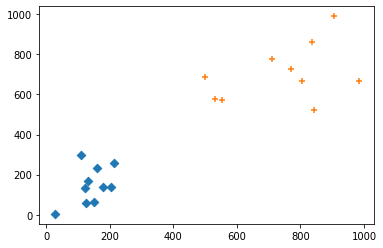

In [270]:
Wolves = []
Sheep = []
init()
print(f"alive sheep is { len( alive_animals(Sheep) ) }")
print( [(w.pos.x, w.pos.y) for w in Wolves])
draw()

[(64.37427544965126, 110.18305951188701), (355.74267531744465, 293.2017203054725), (39.43029797234207, 984.7911847265174), (491.6325478467316, 744.345243905675), (712.1096049091791, 652.6758822049949), (990.498707401411, 45.109170271961), (616.1825822354187, 927.2849350518065), (933.7008571228295, 966.894034498379), (414.0639521017489, 422.67252694120947), (579.590862444413, 737.1515121017807)]


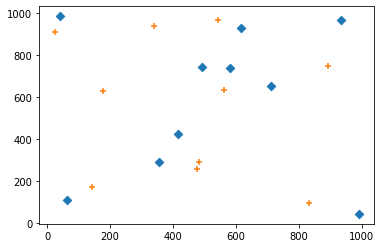

In [296]:
for i in range(300):
    for w in Wolves:
        w.move(DELTA_T)
    for s in alive_animals(Sheep):
        s.move(DELTA_T)
print( [(w.pos.x, w.pos.y) for w in Wolves])
draw()

